In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, lognorm
from scipy.integrate import cumulative_trapezoid

from efpt import aDDModel
from efpt.boundaries import piecewise_const_func

import sys
sys.path.insert(0, "../..")
from shared import generate_sweep_data

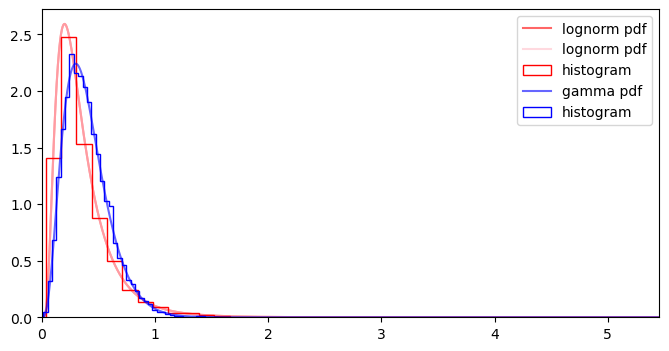

In [3]:
num_samples = 10000
rng = np.random.default_rng()
# sample lognormal waiting times and visualize
mu = 6.39
sigma = 0.63
waitTs1 = rng.lognormal(mean=mu, sigma=sigma, size=num_samples) / 2000

# sample gamma waiting times and visualize
shape_param = 4
scale_param = 0.1
waitTs2 = rng.gamma(shape_param, scale_param, num_samples)


fig, ax = plt.subplots(figsize=(10, 4))
x = np.linspace(0, max(np.max(waitTs1), np.max(waitTs2)), 2000)
ax.plot(x, lognorm.pdf(x, s=sigma, scale=np.exp(mu + np.log(1 / 2000))), "r", alpha=0.6, label="lognorm pdf")
ax.plot(x, lognorm.pdf(x / np.exp(mu + np.log(1 / 2000)), s=sigma) / np.exp(mu + np.log(1 / 2000)), "pink", alpha=0.6, label="lognorm pdf")
ax.hist(waitTs1, histtype="step", bins=40, color="red", density=True, label="histogram")
ax.plot(x, gamma.pdf(x, a=shape_param, scale=scale_param), "b", alpha=0.6, label="gamma pdf")
ax.hist(waitTs2, histtype="step", bins=40, color="blue", density=True, label="histogram")
ax.autoscale(tight=True, axis="x")
ax.set_aspect("equal")
ax.legend()
plt.show()

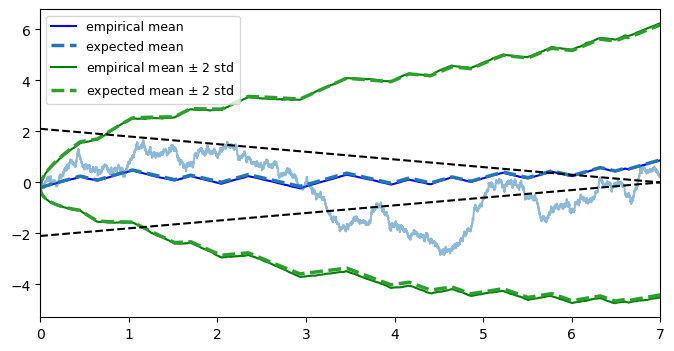

In [4]:
mu1, mu2 = 1.0, -0.8
a, b = 2.1, 0.3
T = a / b
x0 = -0.2

shape_param, scale_param = 4, 0.1
rng = np.random.default_rng()
fixations = rng.gamma(shape_param, scale_param, 1000)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
sacc_array = sacc_array[sacc_array < T]
sigma = 1
num = 2000

model = aDDModel(eta=0.3, kappa=0.5, sigma=sigma, a=a, b=b, x0=x0)
ms = model.to_multistage_model(mu1, mu2, sacc_array)
t_grid, X_grids = ms.simulate_trajs(T=T, Nt=int(1000 * T), num=num)

expected_mean = cumulative_trapezoid(
    piecewise_const_func(t_grid, ms.mu_array, ms.node_array),
    t_grid, initial=0,
) + x0
empirical_mean = np.mean(X_grids, axis=0)
expected_std = sigma * np.sqrt(t_grid)
empirical_std = np.std(X_grids, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, empirical_mean, label="empirical mean", c="b")
ax.plot(t_grid, expected_mean, label="expected mean", linewidth=2.5, linestyle="--", c="tab:blue")
ax.plot(t_grid, empirical_mean + 2 * empirical_std, label=r"empirical mean $\pm$ 2 std", c="g")
ax.plot(t_grid, empirical_mean - 2 * empirical_std, c="g")
ax.plot(t_grid, expected_mean + 2 * expected_std, label=r"expected mean $\pm$ 2 std", linewidth=2.5, linestyle="--", c="tab:green")
ax.plot(t_grid, expected_mean - 2 * expected_std, linewidth=2.5, linestyle="--", c="tab:green")
ax.plot(t_grid, X_grids[:1, :].T, alpha=0.5)
ax.plot(t_grid, ms.upper_bdy(t_grid), c='k', linestyle="--")
ax.plot(t_grid, ms.lower_bdy(t_grid), c='k', linestyle="--")
ax.autoscale(axis="x", tight=True)
ax.legend(fontsize=9)
plt.show()

In [6]:
fixed_params = dict(eta=0.3, kappa=0.5, sigma=1.0, a=2.0, b=0.0, x0=0.5)

combined_path = generate_sweep_data(
    swept_param_name="a",
    swept_values=np.linspace(1.5, 2.5, 11),
    fixed_params=fixed_params,
    n_trials=30000,
    gamma_shape=4.0,
    gamma_scale=0.1,
)
print(f"Saved to: {combined_path}")

Available jobs (CPU cores): 96


Simulating for a=1.5...
Elapsed time: 1560.696 seconds
  -> saved tmp_datasets/addm_data_20260221-232700.pkl
Simulating for a=1.6...
Elapsed time: 1759.516 seconds
  -> saved tmp_datasets/addm_data_20260221-235620.pkl
Simulating for a=1.7...
Elapsed time: 1966.832 seconds
  -> saved tmp_datasets/addm_data_20260222-002907.pkl
Simulating for a=1.8...
Elapsed time: 2232.855 seconds
  -> saved tmp_datasets/addm_data_20260222-010621.pkl
Simulating for a=1.9...
Elapsed time: 2467.626 seconds
  -> saved tmp_datasets/addm_data_20260222-014729.pkl
Simulating for a=2.0...
Elapsed time: 2629.790 seconds
  -> saved tmp_datasets/addm_data_20260222-023120.pkl
Simulating for a=2.1...
Elapsed time: 2850.025 seconds
  -> saved tmp_datasets/addm_data_20260222-031850.pkl
Simulating for a=2.2...
Elapsed time: 3034.486 seconds
  -> saved tmp_datasets/addm_data_20260222-040925.pkl
Simulating for a=2.3...
Elapsed time: 3246.206 seconds
  -> saved tmp_datasets/addm_data_20260222-050332.pkl
Simulating for a=2.

  loaded a=1.5000 from tmp_datasets/addm_data_20260221-232700.pkl
  loaded a=1.6000 from tmp_datasets/addm_data_20260221-235620.pkl
  loaded a=1.7000 from tmp_datasets/addm_data_20260222-002907.pkl
  loaded a=1.8000 from tmp_datasets/addm_data_20260222-010621.pkl
  loaded a=1.9000 from tmp_datasets/addm_data_20260222-014729.pkl
  loaded a=2.0000 from tmp_datasets/addm_data_20260222-023120.pkl
  loaded a=2.1000 from tmp_datasets/addm_data_20260222-031850.pkl
  loaded a=2.2000 from tmp_datasets/addm_data_20260222-040925.pkl
  loaded a=2.3000 from tmp_datasets/addm_data_20260222-050332.pkl
  loaded a=2.4000 from tmp_datasets/addm_data_20260222-060053.pkl
  loaded a=2.5000 from tmp_datasets/addm_data_20260222-070305.pkl

Saved 11 a runs -> addm_data_all_a_20260222-212154.pkl
  deleted tmp_datasets/addm_data_20260221-232700.pkl
  deleted tmp_datasets/addm_data_20260221-235620.pkl
  deleted tmp_datasets/addm_data_20260222-002907.pkl
  deleted tmp_datasets/addm_data_20260222-010621.pkl
  dele